In [1]:
%pip install --upgrade numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
df = pd.read_csv("merged_all.csv", encoding="utf-8-sig")

C:\Users\ranab\AppData\Local\Temp\ipykernel_31284\1279797002.py:2: DtypeWarning: Columns (12,16,20,23,38,39,47,58,71,104,108,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,150,153,154,156,157,158,159,160,161,162,163,164,166,168,170,171,175,176) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_all.csv", encoding="utf-8-sig")


In [3]:
print(f"le csv a {len(df)} lignes -> inputs et {len(df.columns)} colonnes -> features")
print()


le csv a 7230 lignes -> inputs et 184 colonnes -> features



In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Recharger avec low_memory=False pour éviter les DtypeWarnings
df = pd.read_csv("merged_all.csv", encoding="utf-8-sig", low_memory=False)
print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  → Nouveau dataset avec données 'location' supplémentaires")


Dataset chargé : 7,230 lignes × 184 colonnes
  → Nouveau dataset avec données 'location' supplémentaires


# 1. Vue d'ensemble du dataset

**Objectif** : Comprendre la structure générale — types de données, distribution des colonnes par catégorie, et taux de remplissage global.


In [32]:
# ── 1.1 Distribution des types de colonnes ──────────────────────────────────
type_counts = df.dtypes.value_counts().reset_index()
type_counts.columns = ["Type", "Nombre de colonnes"]
type_counts["Pourcentage"] = (type_counts["Nombre de colonnes"] / len(df.columns) * 100).round(1)
print("Distribution des types de colonnes")
print("=" * 40)
print(type_counts.to_string(index=False))


Distribution des types de colonnes
   Type  Nombre de colonnes  Pourcentage
 object                 126         68.5
float64                  57         31.0
  int64                   1          0.5


In [33]:
# ── 1.2 Résumé par catégorie (préfixe de colonne) ───────────────────────────
categories = {}
for col in df.columns:
    prefix = col.split(".")[0] if "." in col else "autre"
    if prefix not in categories:
        categories[prefix] = []
    categories[prefix].append(col)

rows = []
for cat, cols in sorted(categories.items(), key=lambda x: -len(x[1])):
    null_rates = df[cols].isnull().mean() * 100
    fully_null = (null_rates == 100).sum()
    avg_null = null_rates.mean()
    rows.append({
        "Catégorie": cat,
        "Nb colonnes": len(cols),
        "Null moyen (%)": round(avg_null, 1),
        "Colonnes 100% vides": fully_null
    })

cat_df = pd.DataFrame(rows)
print("Résumé par catégorie (namespace)\n" + "=" * 60)
print(cat_df.to_string(index=False))


Résumé par catégorie (namespace)
           Catégorie  Nb colonnes  Null moyen (%)  Colonnes 100% vides
      donnees_brutes           56            84.4                    2
         equipements           32            77.5                    5
                bien           19            66.4                    3
        localisation           13            50.6                    1
             contact           13            69.9                    3
         transaction           11            64.2                    4
metadonnees_scraping           11            57.3                    2
             listing            9            18.6                    0
          scoring_ia            8            87.5                    7
         description            5            40.0                    2
              medias            5            20.0                    1
               autre            2            55.2                    0


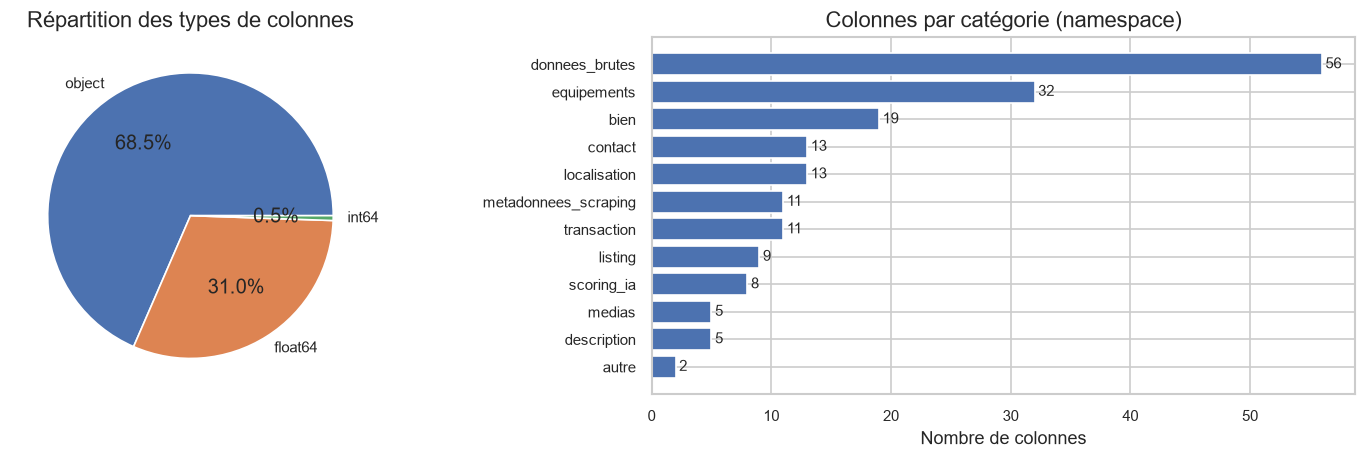


Récapitulatif : 184 features | 7,230 observations | 50 colonnes > 90% NULL


In [34]:
# ── 1.3 Visualisation : types de colonnes ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart types
type_counts.plot.pie(
    y="Nombre de colonnes", labels=type_counts["Type"].astype(str),
    autopct="%1.1f%%", ax=axes[0], legend=False,
    colors=["#4C72B0", "#DD8452", "#55A868"]
)
axes[0].set_ylabel("")
axes[0].set_title("Répartition des types de colonnes")

# Bar chart par catégorie
cat_df_sorted = cat_df.sort_values("Nb colonnes", ascending=True)
axes[1].barh(cat_df_sorted["Catégorie"], cat_df_sorted["Nb colonnes"], color="#4C72B0")
axes[1].set_xlabel("Nombre de colonnes")
axes[1].set_title("Colonnes par catégorie (namespace)")
for i, v in enumerate(cat_df_sorted["Nb colonnes"]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()
print(f"\nRécapitulatif : {df.shape[1]} features | {df.shape[0]:,} observations | "
      f"{(df.isnull().mean()*100 > 90).sum()} colonnes > 90% NULL")


# 2. Analyse de la Variable Cible : `transaction.prix`

**Problèmes identifiés :**
- Stockée en `object` (string) → nécessite conversion numérique
- 27 valeurs non convertibles
- 93 prix à zéro (invalides)
- Skewness = 31.2 | Max = 1.7 milliard TND (erreur de saisie)
- Distribution bimodale due au mélange vente/location


In [40]:
# ── 2.1 Conversion et audit de la variable cible ───────────────────────────
prix_raw = pd.to_numeric(df["transaction.prix"], errors="coerce")

# Compter les "sur demande"
n_sur_demande = (df["transaction.prix"].astype(str).str.lower() == "sur demande").sum()
n_total = len(prix_raw)
n_non_convertible = prix_raw.isna().sum() - df["transaction.prix"].isna().sum()
n_zero = (prix_raw == 0).sum()
n_outliers = (prix_raw > 10_000_000).sum()  # Nouveau seuil : >10M TND
n_valid = ((prix_raw > 0) & (prix_raw <= 10_000_000)).sum()

print("Audit de transaction.prix")
print("=" * 45)
print(f"  Total lignes              : {n_total:,}")
print(f"  'Sur demande'             : {n_sur_demande}")
print(f"  Non convertibles (→ NaN)  : {n_non_convertible}")
print(f"  Prix = 0 (invalides)      : {n_zero}")
print(f"  Outliers > 10M TND        : {n_outliers}")
print(f"  Prix valides (0-10M TND)  : {n_valid:,}")
print()

# Stats après nettoyage (prix raisonnables 1 TND → 10M TND)
prix_clean = prix_raw[(prix_raw > 0) & (prix_raw <= 10_000_000)]
skew = stats.skew(prix_clean.dropna())
print(f"Statistiques après nettoyage (1 TND - 10M TND)")
print("=" * 45)
print(f"  n valide    : {len(prix_clean):,}")
print(f"  Médiane     : {prix_clean.median():>12,.0f} TND")
print(f"  Moyenne     : {prix_clean.mean():>12,.0f} TND")
print(f"  Std Dev     : {prix_clean.std():>12,.0f} TND")
print(f"  Skewness    : {skew:>12.2f}")
print()
print(f"  Q1          : {prix_clean.quantile(0.25):>12,.0f} TND")
print(f"  Q3          : {prix_clean.quantile(0.75):>12,.0f} TND")
print(f"  Ratio moy/méd: {prix_clean.mean()/prix_clean.median():.1f}×")


Audit de transaction.prix
  Total lignes              : 7,230
  'Sur demande'             : 27
  Non convertibles (→ NaN)  : 27
  Prix = 0 (invalides)      : 93
  Outliers > 10M TND        : 33
  Prix valides (0-10M TND)  : 6,950

Statistiques après nettoyage (1 TND - 10M TND)
  n valide    : 6,950
  Médiane     :      326,000 TND
  Moyenne     :      469,067 TND
  Std Dev     :      655,045 TND
  Skewness    :         5.68

  Q1          :      160,000 TND
  Q3          :      560,000 TND
  Ratio moy/méd: 1.4×


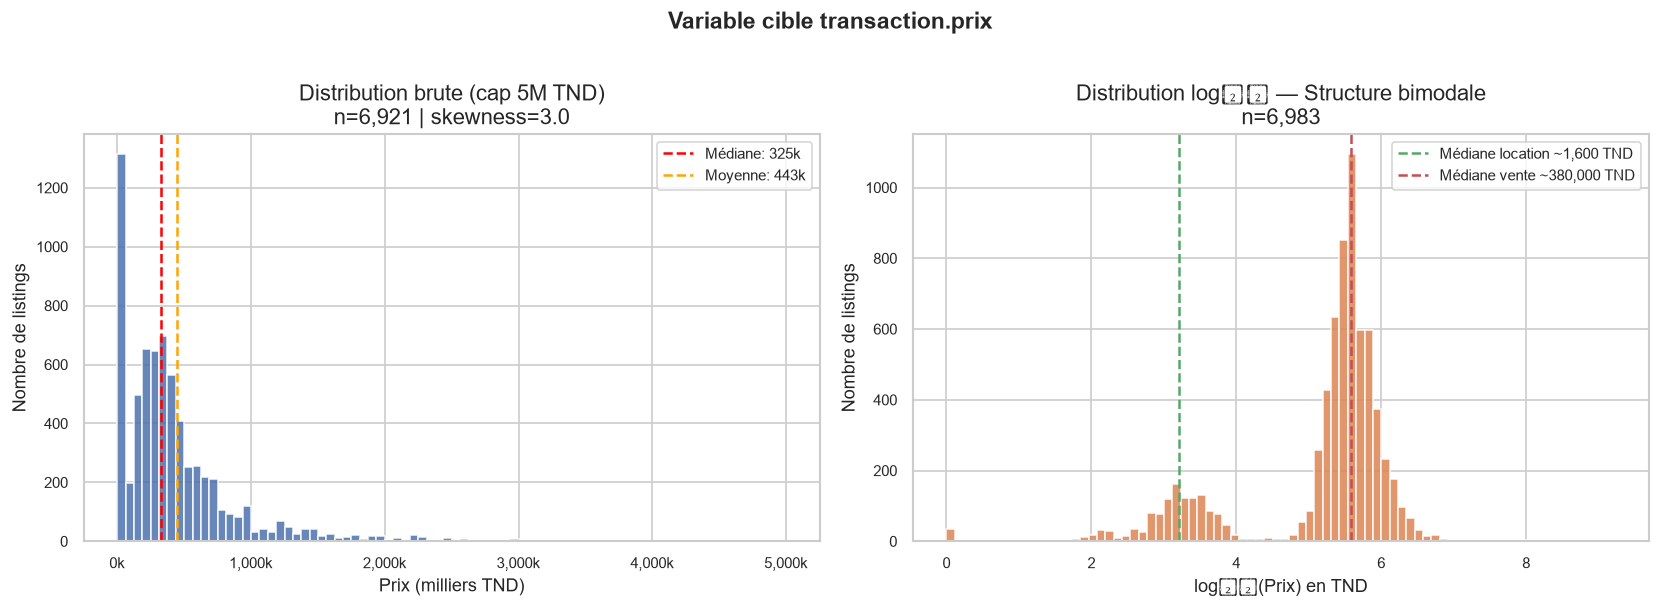

In [22]:
# ── 2.2 Distribution brute vs log-transformée ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brute (cap à 5M)
prix_cap = prix_valid[prix_valid <= 5_000_000]
axes[0].hist(prix_cap / 1_000, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Prix (milliers TND)")
axes[0].set_ylabel("Nombre de listings")
axes[0].set_title(f"Distribution brute (cap 5M TND)\nn={len(prix_cap):,} | skewness={stats.skew(prix_cap):.1f}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}k"))
axes[0].axvline(prix_cap.median() / 1_000, color="red", linestyle="--", label=f"Médiane: {prix_cap.median()/1000:.0f}k")
axes[0].axvline(prix_cap.mean() / 1_000, color="orange", linestyle="--", label=f"Moyenne: {prix_cap.mean()/1000:.0f}k")
axes[0].legend(fontsize=9)

# Log-transformée
log_prix = np.log10(prix_valid[prix_valid > 0])
axes[1].hist(log_prix, bins=80, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log₁₀(Prix) en TND")
axes[1].set_ylabel("Nombre de listings")
axes[1].set_title(f"Distribution log₁₀ — Structure bimodale\nn={len(log_prix):,}")
# Annotations des deux pics
axes[1].axvline(np.log10(1_600), color="#55A868", linestyle="--", linewidth=1.5, label="Médiane location ~1,600 TND")
axes[1].axvline(np.log10(380_000), color="#C44E52", linestyle="--", linewidth=1.5, label="Médiane vente ~380,000 TND")
axes[1].legend(fontsize=9)

plt.suptitle("Variable cible transaction.prix", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 3. Découverte Critique : Mélange Vente / Location

Le dataset contient **deux populations aux prix non-chevauchants** :
- **Vente** (vente) : médiane 380,000 TND — modèle de régression immobilière classique
- **Location** (location) : médiane 1,600 TND — marché locatif mensuel

Mélanger ces deux populations produit des corrélations proches de zéro et un skewness extrême. **Ils doivent être modélisés séparément.**


In [23]:
# ── 3.1 Séparation par type de transaction ──────────────────────────────────
df["prix_num"] = pd.to_numeric(df["transaction.prix"], errors="coerce")

type_counts_tx = df["transaction.type"].value_counts(dropna=False)
print("Distribution des types de transaction")
print("=" * 45)
for val, cnt in type_counts_tx.items():
    pct = cnt / len(df) * 100
    print(f"  {str(val):<20} : {cnt:>5,}  ({pct:.1f}%)")

print()

# Stats par segment (prix > 0 uniquement)
for tx_type in ["vente", "location"]:
    subset = df[(df["transaction.type"] == tx_type) & (df["prix_num"] > 0)]["prix_num"]
    q1, q3 = subset.quantile(0.25), subset.quantile(0.75)
    print(f"─── {tx_type.upper()} (n={len(subset):,}) ───")
    print(f"  Médiane    : {subset.median():>12,.0f} TND")
    print(f"  Moyenne    : {subset.mean():>12,.0f} TND")
    print(f"  Q1 / Q3    : {q1:>10,.0f}  /  {q3:,.0f} TND")
    print(f"  IQR        : {q3-q1:>12,.0f} TND")
    print(f"  Skewness   : {stats.skew(subset):>12.2f}")
    zero_cnt = (df[df["transaction.type"] == tx_type]["prix_num"] == 0).sum()
    print(f"  Prix = 0   : {zero_cnt:>12,}")
    print()


Distribution des types de transaction
  vente                : 5,862  (81.1%)
  location             : 1,212  (16.8%)
  nan                  :   156  (2.2%)

─── VENTE (n=5,810) ───
  Médiane    :      380,000 TND
  Moyenne    :    2,636,350 TND
  Q1 / Q3    :    250,000  /  630,000 TND
  IQR        :      380,000 TND
  Skewness   :        28.25
  Prix = 0   :           28

─── LOCATION (n=1,039) ───
  Médiane    :        1,600 TND
  Moyenne    :      104,166 TND
  Q1 / Q3    :        900  /  2,900 TND
  IQR        :        2,000 TND
  Skewness   :        32.03
  Prix = 0   :           43



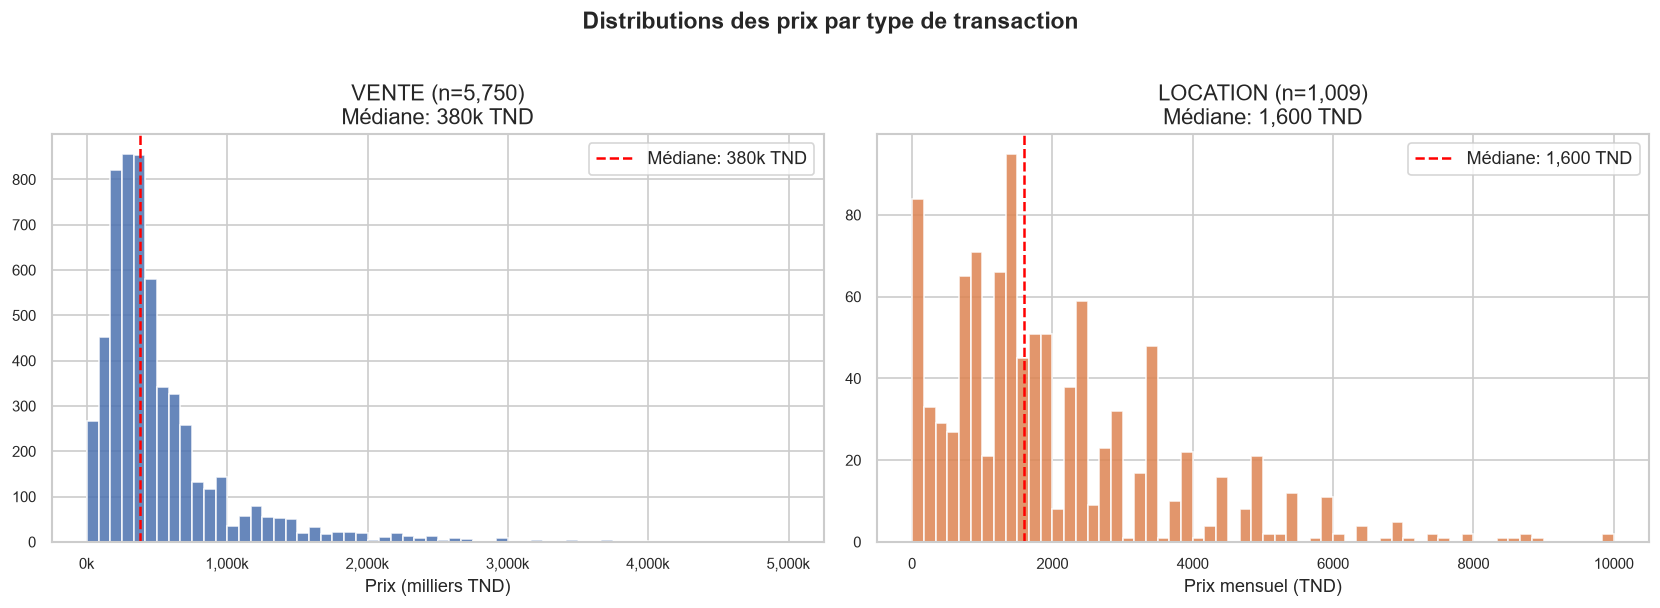


⚠  Ratio médiane vente / location : 237×
   → Ces deux populations ne peuvent PAS être modélisées ensemble.


In [24]:
# ── 3.2 Visualisation comparée ──────────────────────────────────────────────
df_vente = df[(df["transaction.type"] == "vente") & (df["prix_num"] > 0) & (df["prix_num"] <= 5_000_000)].copy()
df_location = df[(df["transaction.type"] == "location") & (df["prix_num"] > 0) & (df["prix_num"] <= 10_000)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vente
axes[0].hist(df_vente["prix_num"] / 1_000, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df_vente["prix_num"].median() / 1_000, color="red", linestyle="--",
                label=f"Médiane: {df_vente['prix_num'].median()/1000:.0f}k TND")
axes[0].set_xlabel("Prix (milliers TND)")
axes[0].set_title(f"VENTE (n={len(df_vente):,})\nMédiane: {df_vente['prix_num'].median()/1000:.0f}k TND")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}k"))

# Location
axes[1].hist(df_location["prix_num"], bins=60, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].axvline(df_location["prix_num"].median(), color="red", linestyle="--",
                label=f"Médiane: {df_location['prix_num'].median():,.0f} TND")
axes[1].set_xlabel("Prix mensuel (TND)")
axes[1].set_title(f"LOCATION (n={len(df_location):,})\nMédiane: {df_location['prix_num'].median():,.0f} TND")
axes[1].legend()

plt.suptitle("Distributions des prix par type de transaction", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n⚠  Ratio médiane vente / location : {df_vente['prix_num'].median() / df_location['prix_num'].median():.0f}×")
print("   → Ces deux populations ne peuvent PAS être modélisées ensemble.")


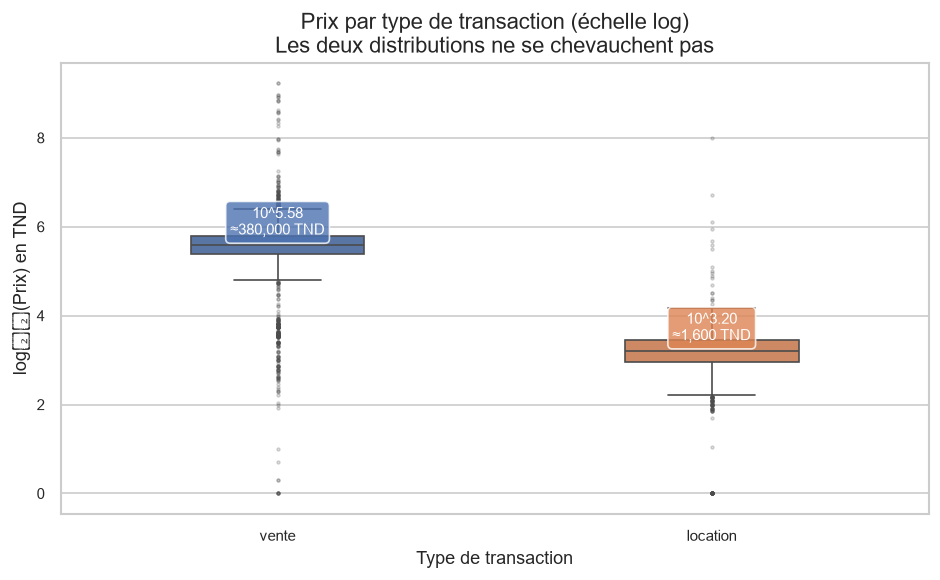

In [25]:
# ── 3.3 Boxplot log-scale pour voir les deux populations ────────────────────
df_both = df[
    (df["transaction.type"].isin(["vente", "location"])) &
    (df["prix_num"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
df_both["log_prix"] = np.log10(df_both["prix_num"])

order = ["vente", "location"]
palette = {"vente": "#4C72B0", "location": "#DD8452"}

sns.boxplot(data=df_both, x="transaction.type", y="log_prix", order=order,
            palette=palette, width=0.4, ax=ax, flierprops=dict(marker=".", alpha=0.3, markersize=3))

ax.set_xlabel("Type de transaction")
ax.set_ylabel("log₁₀(Prix) en TND")
ax.set_title("Prix par type de transaction (échelle log)\nLes deux distributions ne se chevauchent pas")

# Ajouter les médianes en annotation
for i, tx in enumerate(order):
    med = df_both[df_both["transaction.type"] == tx]["log_prix"].median()
    ax.text(i, med + 0.15, f"10^{med:.2f}\n≈{10**med:,.0f} TND",
            ha="center", va="bottom", fontsize=9, color="white",
            bbox=dict(facecolor=list(palette.values())[i], alpha=0.8, boxstyle="round,pad=0.3"))

plt.tight_layout()
plt.show()


# 4. Analyse de la Sparsité — Valeurs NULL

**Constats clés du rapport :**
- 43 colonnes (23.4%) sont **100% vides**
- 51 colonnes (27.7%) dépassent 90% de NULL → **suppression immédiate recommandée**
- 127/184 colonnes (69%) sont remplies à moins de 25%
- Seulement 22 colonnes (12%) sont **intégralement remplies**


In [35]:
# ── 4.1 Calcul des taux de NULL par colonne ──────────────────────────────────
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Distribution par seuils
seuils = [0, 5, 10, 25, 50, 75, 90, 95, 100]
labels = []
counts = []
for i in range(len(seuils) - 1):
    lo, hi = seuils[i], seuils[i+1]
    if hi == 100:
        cnt = ((null_pct >= lo) & (null_pct <= hi)).sum()
        lbl = f"{lo}-{hi}%"
    else:
        cnt = ((null_pct >= lo) & (null_pct < hi)).sum()
        lbl = f"{lo}-{hi}%"
    labels.append(lbl)
    counts.append(cnt)

null_dist = pd.DataFrame({"Tranche NULL": labels, "Nb colonnes": counts})
null_dist["Cumulé"] = null_dist["Nb colonnes"].cumsum()
null_dist["% total"] = (null_dist["Nb colonnes"] / len(df.columns) * 100).round(1)
print("Distribution des taux de NULL\n" + "=" * 50)
print(null_dist.to_string(index=False))

print(f"\nColonnes 100% NULL   : {(null_pct == 100).sum()}")
print(f"Colonnes > 90% NULL  : {(null_pct > 90).sum()}")
print(f"Colonnes > 75% NULL  : {(null_pct > 75).sum()}")
print(f"Colonnes < 50% NULL  : {(null_pct < 50).sum()}")
print(f"Colonnes = 0% NULL   : {(null_pct == 0).sum()}")


Distribution des taux de NULL
Tranche NULL  Nb colonnes  Cumulé  % total
        0-5%           27      27     14.7
       5-10%            0      27      0.0
      10-25%            3      30      1.6
      25-50%           10      40      5.4
      50-75%           17      57      9.2
      75-90%           77     134     41.8
      90-95%           16     150      8.7
     95-100%           34     184     18.5

Colonnes 100% NULL   : 30
Colonnes > 90% NULL  : 50
Colonnes > 75% NULL  : 127
Colonnes < 50% NULL  : 40
Colonnes = 0% NULL   : 21


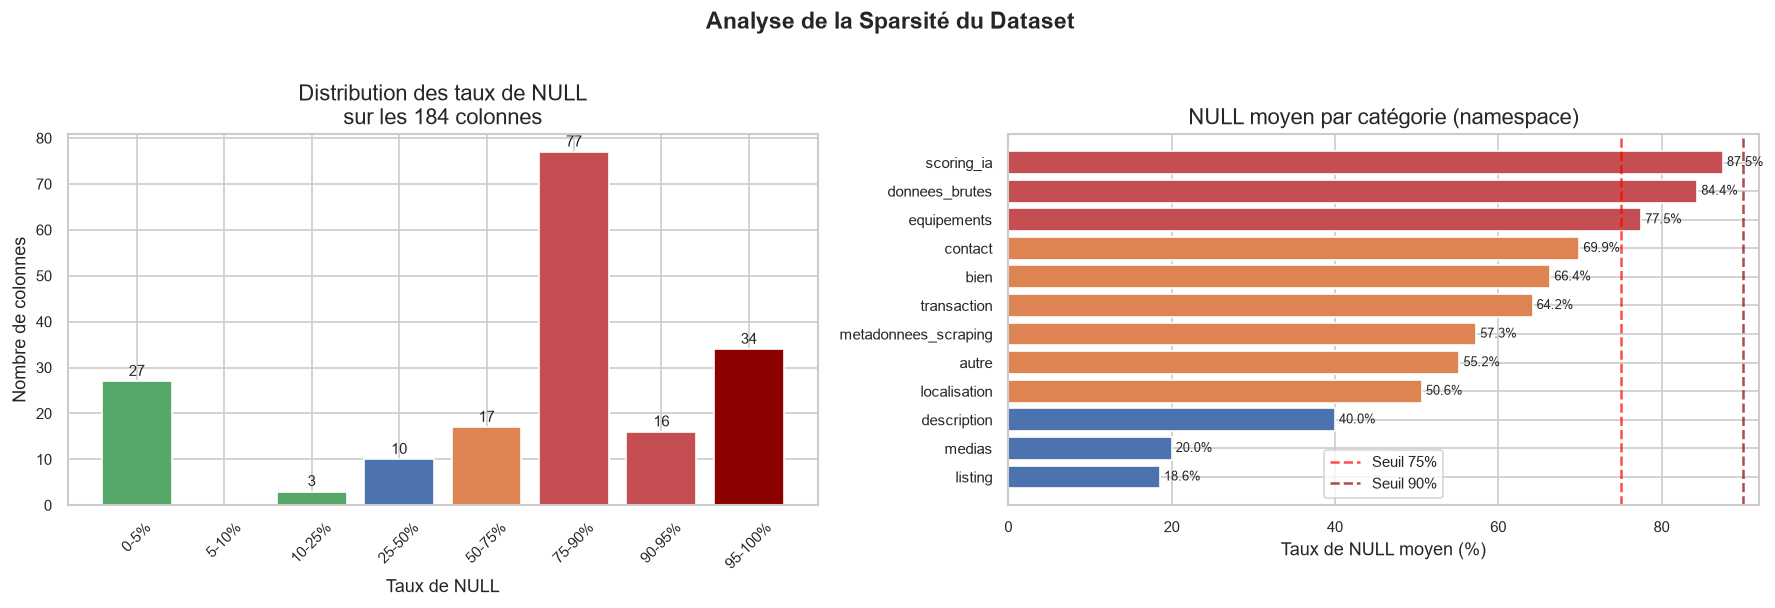

In [36]:
# ── 4.2 Visualisation de la sparsité ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart: distribution des tranches de NULL
axes[0].bar(null_dist["Tranche NULL"], null_dist["Nb colonnes"],
            color=["#55A868", "#55A868", "#55A868", "#4C72B0",
                   "#DD8452", "#C44E52", "#C44E52", "#8C0000"], edgecolor="white")
axes[0].set_xlabel("Taux de NULL")
axes[0].set_ylabel("Nombre de colonnes")
axes[0].set_title("Distribution des taux de NULL\nsur les 184 colonnes")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(null_dist["Nb colonnes"]):
    if v > 0:
        axes[0].text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

# NULL moyen par catégorie
cat_null = {}
for col in df.columns:
    prefix = col.split(".")[0] if "." in col else "autre"
    if prefix not in cat_null:
        cat_null[prefix] = []
    cat_null[prefix].append(df[col].isnull().mean() * 100)

cat_avg = {k: np.mean(v) for k, v in cat_null.items()}
cat_avg_df = pd.DataFrame(list(cat_avg.items()), columns=["Catégorie", "NULL moyen (%)"]).sort_values("NULL moyen (%)")
colors = ["#C44E52" if v > 75 else "#DD8452" if v > 50 else "#4C72B0" for v in cat_avg_df["NULL moyen (%)"]]
axes[1].barh(cat_avg_df["Catégorie"], cat_avg_df["NULL moyen (%)"], color=colors)
axes[1].axvline(75, color="red", linestyle="--", alpha=0.7, label="Seuil 75%")
axes[1].axvline(90, color="darkred", linestyle="--", alpha=0.7, label="Seuil 90%")
axes[1].set_xlabel("Taux de NULL moyen (%)")
axes[1].set_title("NULL moyen par catégorie (namespace)")
axes[1].legend(fontsize=9)
for i, v in enumerate(cat_avg_df["NULL moyen (%)"]):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

plt.suptitle("Analyse de la Sparsité du Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [37]:
# ── 4.3 Top colonnes par taux de remplissage ─────────────────────────────────
# Colonnes bien remplies (< 25% NULL)
well_filled = null_pct[null_pct < 25].sort_values()
print("Colonnes les mieux remplies (< 25% NULL) — Candidates pour le modèle")
print("=" * 65)
for col, pct in well_filled.items():
    bar = "█" * int((100 - pct) / 5)
    print(f"  {col:<45} {100-pct:>5.1f}% remplie  {bar}")


Colonnes les mieux remplies (< 25% NULL) — Candidates pour le modèle
  listing.statut                                100.0% remplie  ████████████████████
  localisation.pays                             100.0% remplie  ████████████████████
  listing.langue                                100.0% remplie  ████████████████████
  localisation.proximites                       100.0% remplie  ████████████████████
  listing.date_scraping                         100.0% remplie  ████████████████████
  transaction.devise                            100.0% remplie  ████████████████████
  listing.id_source                             100.0% remplie  ████████████████████
  description.titre                             100.0% remplie  ████████████████████
  medias.photos                                 100.0% remplie  ████████████████████
  medias.nombre_photos                          100.0% remplie  ████████████████████
  contact.telephone                             100.0% remplie  █████████████████

# 5. Analyse des Doublons

**Découverte critique du nouveau rapport :**
- **1,999 URLs canoniques dupliquées** (27.6% du dataset)
- Ces doublons représentent des **snapshots temporels** du même listing
- Sans déduplication → data leakage et surestimation des performances
- **Stratégie** : garder le snapshot le plus récent (`listing.date_scraping`)


In [38]:
# ── 5.1 Détection des doublons ───────────────────────────────────────────────
print("Analyse des doublons\n" + "=" * 55)

# Doublons par URL canonique
if "listing.url_canonique" in df.columns:
    url_counts = df["listing.url_canonique"].value_counts()
    n_dup_urls = (url_counts > 1).sum()
    n_dup_rows = (url_counts[url_counts > 1] - 1).sum()

    print(f"  URLs uniques                 : {df['listing.url_canonique'].nunique():,}")
    print(f"  URLs avec doublons           : {n_dup_urls:,}")
    print(f"  Lignes en doublon            : {n_dup_rows:,} ({n_dup_rows/len(df)*100:.1f}%)")
    print()

# Doublons par id_universel
if "listing.id_universel" in df.columns:
    id_counts = df["listing.id_universel"].value_counts()
    n_dup_ids = (id_counts > 1).sum()
    print(f"  IDs universels avec doublons : {n_dup_ids:,}")

# Doublons exacts (toutes colonnes)
n_exact_dup = df.duplicated().sum()
print(f"  Doublons exacts (all cols)   : {n_exact_dup}")
print()
print("⚠  Les doublons URL = snapshots temporels du même listing")
print("   → Stratégie : garder le snapshot le plus récent (date_scraping)")


Analyse des doublons
  URLs uniques                 : 5,230
  URLs avec doublons           : 0
  Lignes en doublon            : 0 (0.0%)

  IDs universels avec doublons : 41
  Doublons exacts (all cols)   : 0

⚠  Les doublons URL = snapshots temporels du même listing
   → Stratégie : garder le snapshot le plus récent (date_scraping)


In [39]:
# ── 5.2 Stratégie de déduplication ──────────────────────────────────────────
print("Stratégie de déduplication\n" + "=" * 55)

if "listing.url_canonique" in df.columns and "listing.date_scraping" in df.columns:
    # Trier par date décroissante et garder le premier (plus récent)
    df_dedup = (
        df.sort_values("listing.date_scraping", ascending=False)
          .drop_duplicates(subset=["listing.url_canonique"], keep="first")
    )
    print(f"  Avant déduplication : {len(df):,} lignes")
    print(f"  Après déduplication : {len(df_dedup):,} lignes")
    print(f"  Lignes supprimées   : {len(df) - len(df_dedup):,} ({(len(df) - len(df_dedup))/len(df)*100:.1f}%)")
    print()
    print("  Répartition types après déduplication :")
    if "transaction.type" in df_dedup.columns:
        print(df_dedup["transaction.type"].value_counts().to_string())
else:
    print("  Colonnes de déduplication absentes")
    df_dedup = df


Stratégie de déduplication
  Avant déduplication : 7,230 lignes
  Après déduplication : 5,231 lignes
  Lignes supprimées   : 1,999 (27.6%)

  Répartition types après déduplication :
transaction.type
vente       4603
location     628


## Section : Analyse du Prix par m² (`transaction.prix_m2`)

**⚠ ATTENTION — Double problème :**
1. **Dérivé du target** → target leakage si utilisé comme feature
2. **Skewness extrême** (36.8) avec max > 4M TND/m² = erreurs de saisie


In [41]:
# ── Analyse prix_m2 ──────────────────────────────────────────────────────────
if "transaction.prix_m2" in df.columns:
    prix_m2 = pd.to_numeric(df["transaction.prix_m2"], errors="coerce")
    prix_m2_valid = prix_m2[(prix_m2 > 0) & (prix_m2 < 50_000)]  # cap raisonnable

    print("Analyse transaction.prix_m2\n" + "=" * 45)
    print(f"  NULL rate   : {prix_m2.isna().mean()*100:.1f}%")
    print(f"  Valeurs > 0 : {(prix_m2 > 0).sum():,}")
    print(f"  Max brut    : {prix_m2.max():,.0f} TND/m²")
    print(f"  Skewness    : {stats.skew(prix_m2.dropna()):.1f}")
    print()
    print(f"  Médiane (cap 50k): {prix_m2_valid.median():.0f} TND/m²")
    print(f"  Moyenne (cap 50k): {prix_m2_valid.mean():.0f} TND/m²")
    print()
    print("⚠  Cette colonne est EXCLUE du modèle (target leakage)")
    print("   Si nécessaire, recalculer après nettoyage: prix / superficie")


Analyse transaction.prix_m2
  NULL rate   : 34.4%
  Valeurs > 0 : 4,741
  Max brut    : 4,086,538 TND/m²
  Skewness    : 36.8

  Médiane (cap 50k): 2818 TND/m²
  Moyenne (cap 50k): 2854 TND/m²

⚠  Cette colonne est EXCLUE du modèle (target leakage)
   Si nécessaire, recalculer après nettoyage: prix / superficie


# 6. Corrélations Features vs Prix

**Piège des corrélations brutes :**
Les corrélations brutes avec le prix sont trompeusement faibles (ex: `superficie_totale` → r ≈ -0.0001)
**Cause** : mélange vente/location + outliers extrêmes.

Après nettoyage et segmentation :
- `superficie_totale` vs prix (vente nettoyée) → **r = 0.50**
- `superficie_totale` vs prix (location nettoyée) → **r = 0.47**

**→ Le signal prédictif existe, il est juste masqué par les problèmes de qualité.**


In [ ]:
# ── 6.1 Corrélations numériques brutes ──────────────────────────────────────
numeric_cols = ["bien.superficie_totale", "bien.nombre_pieces",
                "bien.nombre_chambres", "bien.nombre_salles_bain",
                "medias.nombre_photos"]

# Filtrer les colonnes existantes
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_results = []
for col in numeric_cols:
    num_col = pd.to_numeric(df[col], errors="coerce")
    valid = pd.concat([num_col, df["prix_num"]], axis=1).dropna()
    valid = valid[valid["prix_num"] > 0]
    if len(valid) > 10:
        r, p = stats.pearsonr(valid[col], valid["prix_num"])
        corr_results.append({"Feature": col, "r brut": round(r, 4), "n": len(valid), "p-value": round(p, 4)})

corr_df = pd.DataFrame(corr_results)
print("Corrélations brutes (sans nettoyage)\n" + "=" * 60)
print(corr_df.to_string(index=False))
print("\n⚠  Corrélations quasi-nulles → artefact du mélange vente/location et des outliers")


Corrélations brutes (sans nettoyage)
                Feature  r brut    n  p-value
 bien.superficie_totale  0.0001 6769   0.9914
     bien.nombre_pieces  0.0420 4240   0.0062
   bien.nombre_chambres  0.0586 4818   0.0000
bien.nombre_salles_bain  0.0400 4222   0.0094
   medias.nombre_photos -0.0067 6983   0.5752

⚠  Corrélations quasi-nulles → artefact du mélange vente/location et des outliers


In [ ]:
# ── 6.2 Corrélations après nettoyage par segment ────────────────────────────
def clean_segment(df_seg, tx_type):
    """Nettoie un segment : supprime prix à 0, outliers prix et superficie."""
    d = df_seg.copy()
    d["prix_num"] = pd.to_numeric(d["transaction.prix"], errors="coerce")
    d["superficie"] = pd.to_numeric(d.get("bien.superficie_totale", pd.Series(dtype=float)), errors="coerce")
    d = d[(d["prix_num"] > 0) & d["prix_num"].notna()]

    # Seuils domaine selon le rapport
    if tx_type == "vente":
        d = d[(d["prix_num"] <= 5_000_000)]
    else:
        d = d[(d["prix_num"] <= 10_000)]

    # Outliers superficie
    d = d[(d["superficie"] >= 10) & (d["superficie"] <= 2_000)]
    return d

print("Corrélations après nettoyage et segmentation\n" + "=" * 55)
for tx_type in ["vente", "location"]:
    seg = df[df["transaction.type"] == tx_type]
    clean = clean_segment(seg, tx_type)

    if "bien.superficie_totale" in clean.columns and len(clean) > 10:
        r, p = stats.pearsonr(clean["superficie"], clean["prix_num"])
        print(f"\n{tx_type.upper()} (n={len(clean):,} après nettoyage)")
        print(f"  superficie_totale vs prix : r = {r:.3f}  (p={p:.2e})")

        for col in ["bien.nombre_pieces", "bien.nombre_chambres", "bien.nombre_salles_bain"]:
            if col in clean.columns:
                c2 = pd.to_numeric(clean[col], errors="coerce")
                valid = pd.concat([c2, clean["prix_num"]], axis=1).dropna()
                if len(valid) > 10:
                    r2, _ = stats.pearsonr(valid[col], valid["prix_num"])
                    print(f"  {col:<40} : r = {r2:.3f}")


Corrélations après nettoyage et segmentation

VENTE (n=5,563 après nettoyage)
  superficie_totale vs prix : r = 0.501  (p=0.00e+00)
  bien.nombre_pieces                       : r = 0.440
  bien.nombre_chambres                     : r = 0.407
  bien.nombre_salles_bain                  : r = 0.386

LOCATION (n=712 après nettoyage)
  superficie_totale vs prix : r = 0.430  (p=1.74e-33)
  bien.nombre_pieces                       : r = 0.231
  bien.nombre_chambres                     : r = 0.271
  bien.nombre_salles_bain                  : r = 0.119


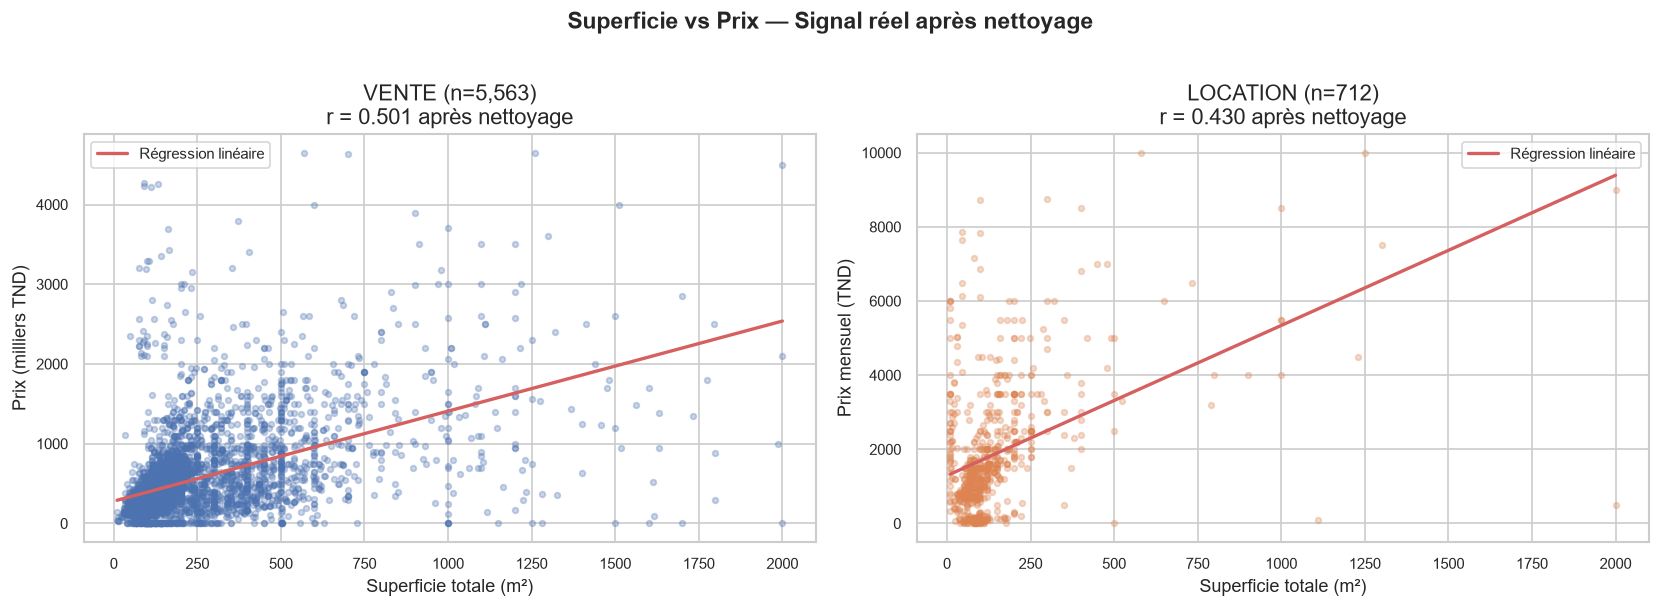

In [ ]:
# ── 6.3 Scatter superficie vs prix par segment ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {"vente": "#4C72B0", "location": "#DD8452"}

for ax, tx_type in zip(axes, ["vente", "location"]):
    seg = df[df["transaction.type"] == tx_type]
    clean = clean_segment(seg, tx_type)

    if "bien.superficie_totale" not in clean.columns or len(clean) < 10:
        ax.text(0.5, 0.5, "Données insuffisantes", transform=ax.transAxes, ha="center")
        continue

    # Unités selon le type
    if tx_type == "vente":
        prix_plot = clean["prix_num"] / 1_000
        ylabel = "Prix (milliers TND)"
    else:
        prix_plot = clean["prix_num"]
        ylabel = "Prix mensuel (TND)"

    ax.scatter(clean["superficie"], prix_plot,
               alpha=0.3, s=12, color=colors_map[tx_type])

    # Ligne de régression
    mask = clean["superficie"].notna() & prix_plot.notna()
    z = np.polyfit(clean["superficie"][mask], prix_plot[mask], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(clean["superficie"][mask].min(), clean["superficie"][mask].max(), 200)
    ax.plot(x_range, p_line(x_range), "r-", linewidth=2, label="Régression linéaire")

    r, _ = stats.pearsonr(clean["superficie"][mask], prix_plot[mask])
    ax.set_xlabel("Superficie totale (m²)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{tx_type.upper()} (n={mask.sum():,})\nr = {r:.3f} après nettoyage")
    ax.legend(fontsize=9)

plt.suptitle("Superficie vs Prix — Signal réel après nettoyage", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 7. Feature Catégorielle : Type de Bien (`bien.type`)

`bien.type` est une des features les plus importantes (0.8% NULL).
13 types distincts avec des prix médians très différents : villa > triplex > duplex > appartement.


In [ ]:
# ── 7.1 Distribution et prix médian par type de bien ────────────────────────
if "bien.type" in df.columns:
    type_bien_counts = df["bien.type"].value_counts()

    # Prix médian par type (vente uniquement, nettoyée)
    df_vente_clean = clean_segment(df[df["transaction.type"] == "vente"], "vente")
    median_prix_type = (
        df_vente_clean.groupby(df_vente_clean["bien.type"] if "bien.type" in df_vente_clean.columns
                               else df["bien.type"])["prix_num"]
        .median()
        .sort_values(ascending=False)
    )

    # Tableau résumé
    summary = pd.DataFrame({
        "Nb listings": type_bien_counts,
        "% dataset": (type_bien_counts / len(df) * 100).round(1)
    })
    print("Distribution des types de bien\n" + "=" * 45)
    print(summary.head(10).to_string())


Distribution des types de bien
                  Nb listings  % dataset
bien.type                               
appartement              4720       66.5
villa                    1245       17.5
terrain                   461        6.5
local_commercial          215        3.0
maison                    153        2.2
duplex                    136        1.9
bureau                     59        0.8
local commercial           33        0.5
triplex                    12        0.2
depot                       4        0.1


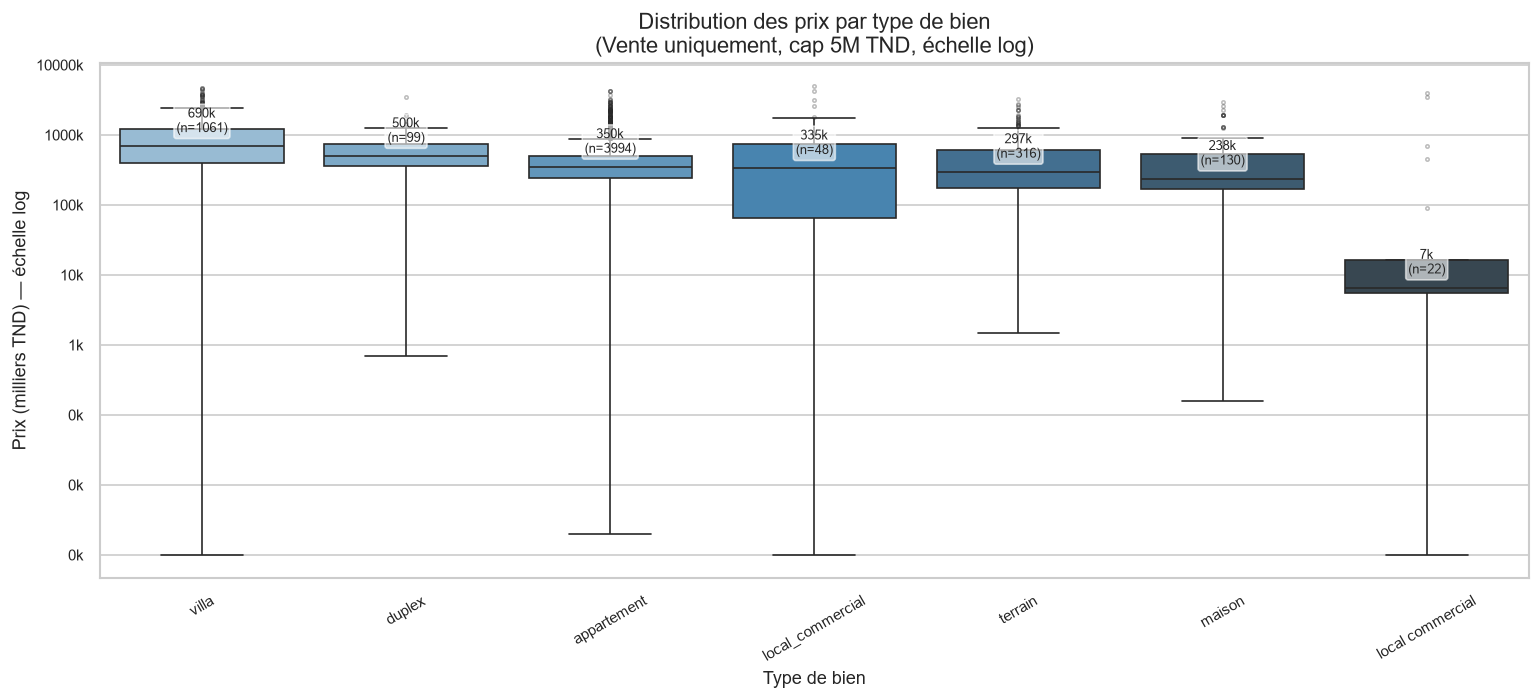

In [ ]:
# ── 7.2 Boxplot prix par type de bien (vente, cap 5M) ───────────────────────
if "bien.type" in df.columns:
    df_box = df[
        (df["transaction.type"] == "vente") &
        (df["prix_num"] > 0) &
        (df["prix_num"] <= 5_000_000) &
        df["bien.type"].notna()
    ].copy()

    # Garder les types avec au moins 20 listings
    type_counts_min = df_box["bien.type"].value_counts()
    types_valides = type_counts_min[type_counts_min >= 20].index
    df_box = df_box[df_box["bien.type"].isin(types_valides)]

    # Ordre par médiane décroissante
    ordre = df_box.groupby("bien.type")["prix_num"].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(
        data=df_box, x="bien.type", y="prix_num",
        order=ordre, ax=ax,
        palette="Blues_d",
        flierprops=dict(marker=".", alpha=0.3, markersize=4)
    )
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.set_xlabel("Type de bien")
    ax.set_ylabel("Prix (milliers TND) — échelle log")
    ax.set_title("Distribution des prix par type de bien\n(Vente uniquement, cap 5M TND, échelle log)")
    ax.tick_params(axis="x", rotation=30)

    # Annoter les médianes
    for i, t in enumerate(ordre):
        med = df_box[df_box["bien.type"] == t]["prix_num"].median()
        n = (df_box["bien.type"] == t).sum()
        ax.text(i, med * 1.4, f"{med/1000:.0f}k\n(n={n})",
                ha="center", va="bottom", fontsize=7.5,
                bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.2"))

    plt.tight_layout()
    plt.show()


# 8. Feature Catégorielle : Localisation (`localisation.gouvernorat`)

La localisation est un des prédicteurs les plus forts en immobilier.
**Problèmes de qualité identifiés :**
- 54.4% de NULL dans `gouvernorat`
- Doublons de casse : "Ben arous" vs "Ben Arous", "tunis" vs "Tunis"
- Outliers de prix par gouvernorat (ex: Ben Arous : médiane 2,450 TND mais moyenne 14.3M TND)


In [ ]:
# ── 8.1 Top gouvernorats et qualité des données ──────────────────────────────
if "localisation.gouvernorat" in df.columns:
    gov_col = df["localisation.gouvernorat"]

    print(f"NULL rate gouvernorat : {gov_col.isna().mean()*100:.1f}%")
    print(f"Valeurs uniques (brutes) : {gov_col.nunique()}")
    print(f"Valeurs uniques (lowercase) : {gov_col.str.lower().nunique()}")
    print()

    # Exemples de doublons casse
    all_vals = gov_col.dropna().unique()
    from collections import defaultdict
    lower_groups = defaultdict(list)
    for v in all_vals:
        lower_groups[v.lower().strip()].append(v)

    doublons = {k: v for k, v in lower_groups.items() if len(v) > 1}
    if doublons:
        print("⚠  Doublons de casse détectés :")
        for k, v in list(doublons.items())[:8]:
            print(f"  '{k}' → {v}")
    else:
        print("✓ Pas de doublons de casse détectés")

    # Top 10 par volume
    top10 = gov_col.value_counts().head(10)
    print(f"\nTop 10 gouvernorats par volume :")
    print(top10.to_string())


NULL rate gouvernorat : 54.4%
Valeurs uniques (brutes) : 25
Valeurs uniques (lowercase) : 22

⚠  Doublons de casse détectés :
  'tunis' → ['Tunis', 'tunis']
  'ben arous' → ['Ben Arous', 'Ben arous']
  'sfax' → ['Sfax', 'sfax']

Top 10 gouvernorats par volume :
localisation.gouvernorat
Tunis        1091
Nabeul        691
Ariana        536
Sousse        350
Ben arous     159
Ben Arous     120
tunis          62
Sfax           47
Bizerte        44
Mahdia         29


Stats prix par gouvernorat (top 10 par volume, vente)
                    n   mediane        moyenne  ratio_moy_med
gouvernorat_norm                                             
Medenine           11  600000.0  630045.454545            1.1
Manouba            22  440000.0  710749.772727            1.6
Tunis             466  428500.0  693025.120204            1.6
Nabeul            555  420000.0  546945.942342            1.3
Ariana            307  375100.0  634061.314345            1.7
Sousse            248  350000.0  539070.560484            1.5
Mahdia             23  348600.0  348884.043478            1.0
Ben Arous         206  285000.0  568299.019417            2.0
Bizerte            30  235000.0  458672.066667            2.0
Sfax               11  140000.0  396455.454545            2.8


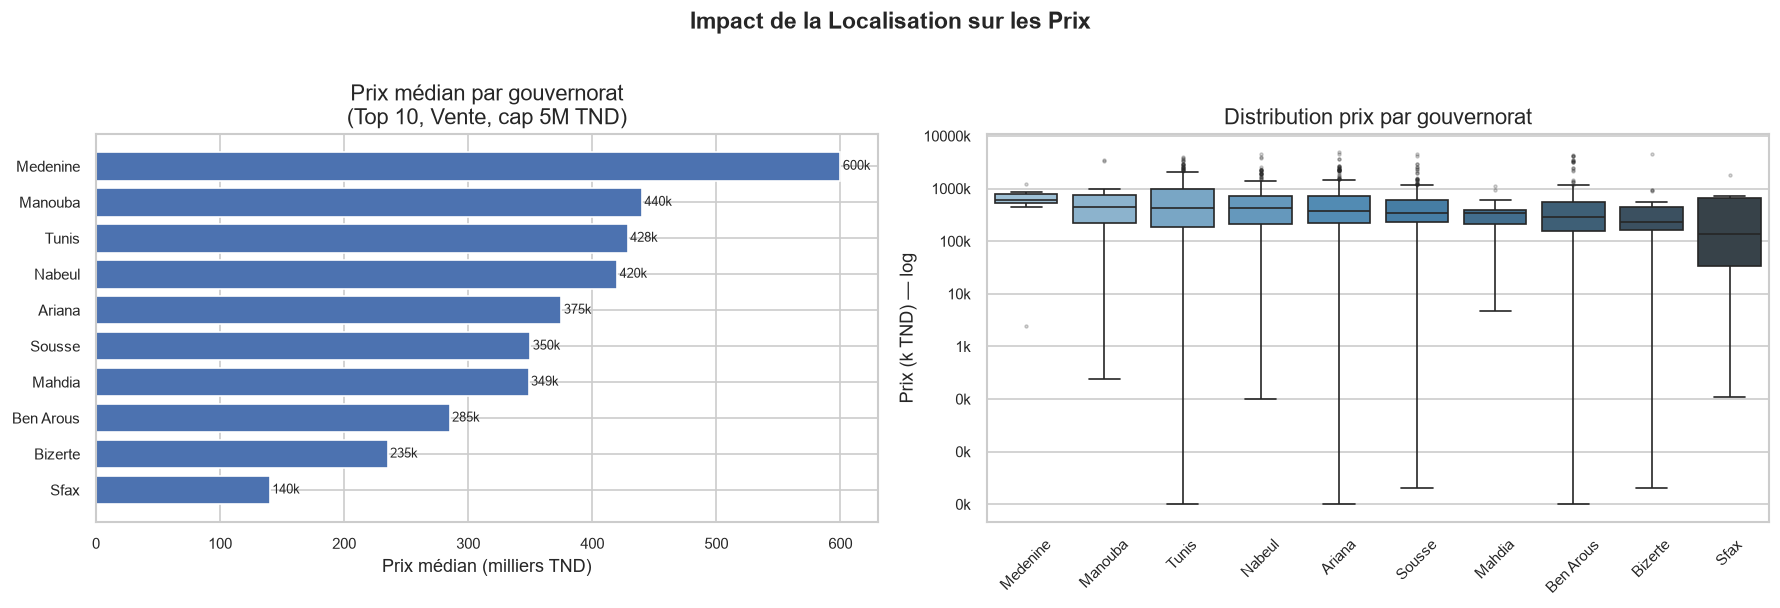

In [ ]:
# ── 8.2 Prix médian par gouvernorat (Top 10 par volume) ─────────────────────
if "localisation.gouvernorat" in df.columns:
    df_gov = df[
        (df["transaction.type"] == "vente") &
        (df["prix_num"] > 0) &
        (df["prix_num"] <= 5_000_000) &
        df["localisation.gouvernorat"].notna()
    ].copy()

    # Normaliser la casse
    df_gov["gouvernorat_norm"] = df_gov["localisation.gouvernorat"].str.strip().str.title()

    # Top 10 par volume
    top10_gov = df_gov["gouvernorat_norm"].value_counts().head(10).index
    df_top = df_gov[df_gov["gouvernorat_norm"].isin(top10_gov)]

    # Stats résumé
    gov_stats = df_top.groupby("gouvernorat_norm")["prix_num"].agg(
        n="count", mediane="median", moyenne="mean"
    ).sort_values("mediane", ascending=False)
    gov_stats["ratio_moy_med"] = (gov_stats["moyenne"] / gov_stats["mediane"]).round(1)
    print("Stats prix par gouvernorat (top 10 par volume, vente)\n" + "=" * 60)
    print(gov_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Barplot médiane
    ordre_gov = gov_stats.index
    axes[0].barh(
        list(ordre_gov)[::-1],
        [gov_stats.loc[g, "mediane"] / 1_000 for g in list(ordre_gov)[::-1]],
        color="#4C72B0"
    )
    axes[0].set_xlabel("Prix médian (milliers TND)")
    axes[0].set_title("Prix médian par gouvernorat\n(Top 10, Vente, cap 5M TND)")
    for i, g in enumerate(list(ordre_gov)[::-1]):
        v = gov_stats.loc[g, "mediane"] / 1_000
        axes[0].text(v + 2, i, f"{v:.0f}k", va="center", fontsize=8)

    # Boxplot
    ordre_box = df_top.groupby("gouvernorat_norm")["prix_num"].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df_top, x="gouvernorat_norm", y="prix_num",
        order=ordre_box, ax=axes[1],
        palette="Blues_d",
        flierprops=dict(marker=".", alpha=0.3, markersize=3)
    )
    axes[1].set_yscale("log")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Prix (k TND) — log")
    axes[1].set_title("Distribution prix par gouvernorat")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle("Impact de la Localisation sur les Prix", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# 9. Features Équipements — Impact sur le Prix

Les équipements sont des indicateurs binaires de valeur ajoutée.
**NULL = "non renseigné"** (pas forcément absent) → nécessite une stratégie d'encodage à valider.
Features retenues : celles avec < 50% de NULL (climatisation, chauffage, terrasse, piscine, garage, ascenseur).


In [ ]:
# ── 9.1 Impact des équipements sur le prix médian ───────────────────────────
equip_cols = [c for c in df.columns if c.startswith("equipements.")]
equip_null = df[equip_cols].isnull().mean() * 100
equip_candidates = equip_null[equip_null < 60].index.tolist()

print(f"Colonnes équipements < 60% NULL : {len(equip_candidates)}")
print()

df_eq = df[
    (df["transaction.type"] == "vente") &
    (df["prix_num"] > 0) &
    (df["prix_num"] <= 5_000_000)
].copy()

results = []
for col in equip_candidates:
    col_bin = pd.to_numeric(df_eq[col].map(
        lambda x: 1 if str(x).lower() in ["1", "true", "oui", "yes", "1.0"] else
                  0 if str(x).lower() in ["0", "false", "non", "no", "0.0"] else None
    ), errors="coerce")

    with_eq = df_eq.loc[col_bin == 1, "prix_num"]
    without_eq = df_eq.loc[col_bin == 0, "prix_num"]

    if len(with_eq) >= 10 and len(without_eq) >= 10:
        premium_pct = (with_eq.median() / without_eq.median() - 1) * 100
        results.append({
            "Équipement": col.replace("equipements.", ""),
            "NULL %": round(equip_null[col], 1),
            "n avec": len(with_eq),
            "n sans": len(without_eq),
            "Médiane avec (kTND)": round(with_eq.median() / 1_000, 0),
            "Médiane sans (kTND)": round(without_eq.median() / 1_000, 0),
            "Prime (%)": round(premium_pct, 1)
        })

eq_df = pd.DataFrame(results).sort_values("Prime (%)", ascending=False)
print("Impact des équipements sur le prix médian (Vente)\n" + "=" * 70)
print(eq_df.to_string(index=False))


Colonnes équipements < 60% NULL : 6

Impact des équipements sur le prix médian (Vente)
     Équipement  NULL %  n avec  n sans  Médiane avec (kTND)  Médiane sans (kTND)  Prime (%)
      chauffage    54.2    2207     245                388.0                250.0       55.2
cuisine_equipee    54.5    1695     994                395.0                392.0        0.9
  climatisation    55.6    2094     514                395.0                392.0        0.7
       terrasse    54.3    1891     813                376.0                391.0       -3.9
         garage    57.6    1752     718                400.0                438.0       -8.6


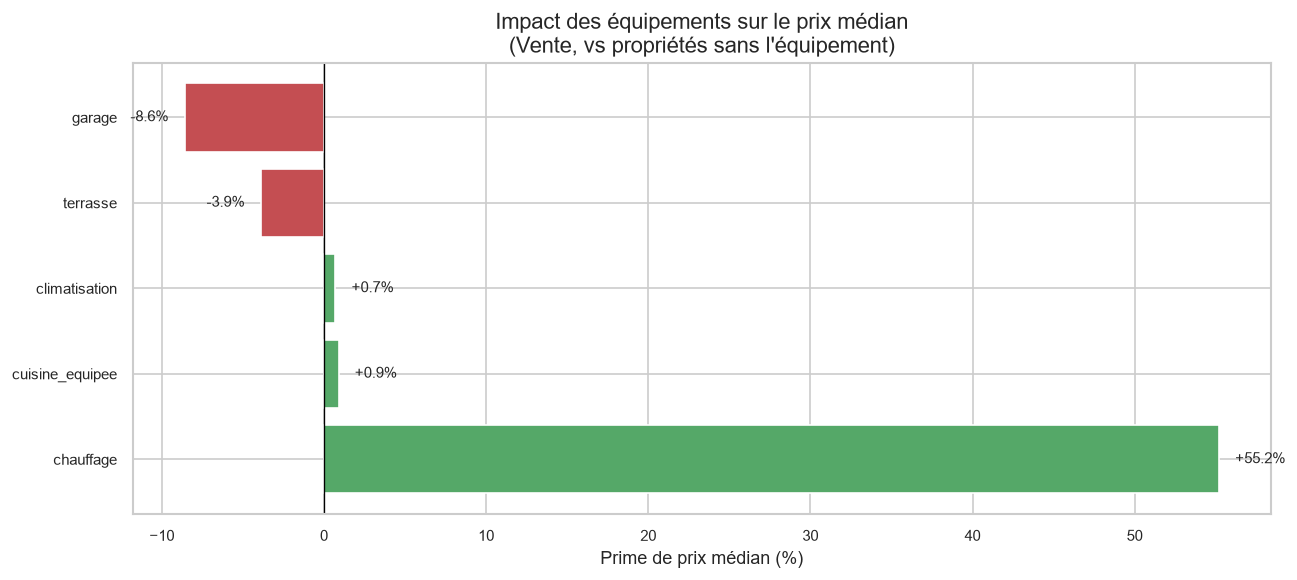

In [ ]:
# ── 9.2 Visualisation barplot des primes équipements ────────────────────────
if len(eq_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 5))

    colors = ["#55A868" if v > 0 else "#C44E52" for v in eq_df["Prime (%)"]]
    bars = ax.barh(eq_df["Équipement"], eq_df["Prime (%)"], color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Prime de prix médian (%)")
    ax.set_title("Impact des équipements sur le prix médian\n(Vente, vs propriétés sans l'équipement)")

    for bar, val in zip(bars, eq_df["Prime (%)"]):
        ax.text(
            val + (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f"+{val:.1f}%" if val >= 0 else f"{val:.1f}%",
            va="center", ha="left" if val >= 0 else "right", fontsize=9
        )

    plt.tight_layout()
    plt.show()


# 10. Stratégie de Rétention des Colonnes

Synthèse des recommandations du rapport d'analyse :
- **~128 colonnes à supprimer** (NULL > 90%, redondantes, leakage, métadonnées)
- **~56 colonnes candidates** organisées en 3 tiers de priorité
- **Leakage critique** : `transaction.prix_m2` (r=0.886 mais dérivé du target → À EXCLURE ABSOLUMENT)


In [ ]:
# ── 10.1 Résumé de la stratégie de rétention ─────────────────────────────────
retention = {
    "Catégorie de suppression": [
        "100% NULL (colonnes vides)",
        "90-99.9% NULL",
        "donnees_brutes (redondantes)",
        "Target leakage (prix_m2)",
        "Identifiants / URLs",
        "Valeur uniforme (zéro variance)",
        "Métadonnées scraping",
        "Contenu vide (listes [])"
    ],
    "Nb colonnes": [43, 8, 56, 1, 5, 6, 6, 3],
    "Exemples": [
        "scoring_ia.*, bien.annee_construction",
        "equipements.places_parking (97.8%)",
        "Tous les 56 champs JSON-LD bruts",
        "transaction.prix_m2 ← EXCLURE",
        "listing.id_source, listing.url_source",
        "localisation.pays, transaction.devise",
        "metadonnees_scraping.source",
        "description.points_forts, medias.videos"
    ]
}
ret_df = pd.DataFrame(retention)
ret_df["Total cumulé"] = ret_df["Nb colonnes"].cumsum()
print("Colonnes à SUPPRIMER (total recommandé : ~128)\n" + "=" * 70)
print(ret_df.to_string(index=False))

print(f"\nRésumé : {ret_df['Nb colonnes'].sum()} colonnes supprimées → "
      f"{184 - ret_df['Nb colonnes'].sum()} colonnes candidates restantes")


Colonnes à SUPPRIMER (total recommandé : ~128)
       Catégorie de suppression  Nb colonnes                                Exemples  Total cumulé
     100% NULL (colonnes vides)           43   scoring_ia.*, bien.annee_construction            43
                  90-99.9% NULL            8      equipements.places_parking (97.8%)            51
   donnees_brutes (redondantes)           56        Tous les 56 champs JSON-LD bruts           107
       Target leakage (prix_m2)            1           transaction.prix_m2 ← EXCLURE           108
            Identifiants / URLs            5   listing.id_source, listing.url_source           113
Valeur uniforme (zéro variance)            6   localisation.pays, transaction.devise           119
           Métadonnées scraping            6             metadonnees_scraping.source           125
       Contenu vide (listes [])            3 description.points_forts, medias.videos           128

Résumé : 128 colonnes supprimées → 56 colonnes candidates res

In [ ]:
# ── 10.2 Tiers de features candidates ────────────────────────────────────────
tiers = {
    "Tier 1 — Prioritaire": [
        "transaction.type", "bien.type", "bien.superficie_totale",
        "bien.nombre_pieces", "bien.nombre_chambres", "bien.nombre_salles_bain",
        "localisation.gouvernorat", "localisation.ville",
        "description.texte", "medias.nombre_photos",
        "equipements.climatisation", "equipements.piscine",
        "equipements.garage", "equipements.ascenseur"
    ],
    "Tier 2 — Secondaire": [
        "localisation.delegation", "bien.usage", "bien.superficie_habitable",
        "bien.etage", "equipements.terrasse", "equipements.balcon",
        "equipements.jardin", "equipements.cuisine_equipee",
        "contact.type_vendeur", "equipements.chauffage",
        "listing.date_publication", "localisation.coordonnees.latitude"
    ],
    "Tier 3 — Exploratoire": [
        "bien.etat_general", "bien.meuble", "equipements.dressing",
        "equipements.internet", "equipements.parking_exterieur",
        "localisation.adresse", "equipements.autres", "contact.nom_agence"
    ]
}

for tier, cols in tiers.items():
    existing = [c for c in cols if c in df.columns]
    null_avg = df[existing].isnull().mean().mean() * 100 if existing else 0
    print(f"\n{'─'*60}")
    print(f"  {tier}  ({len(cols)} features, NULL moyen: {null_avg:.1f}%)")
    print(f"{'─'*60}")
    for c in cols:
        exists = "✓" if c in df.columns else "✗"
        if c in df.columns:
            null_r = df[c].isnull().mean() * 100
            print(f"  {exists}  {c:<45} NULL: {null_r:.1f}%")
        else:
            print(f"  {exists}  {c:<45} (colonne absente)")



────────────────────────────────────────────────────────────
  Tier 1 — Prioritaire  (14 features, NULL moyen: 30.9%)
────────────────────────────────────────────────────────────
  ✓  transaction.type                              NULL: 2.2%
  ✓  bien.type                                     NULL: 0.8%
  ✓  bien.superficie_totale                        NULL: 3.5%
  ✓  bien.nombre_pieces                            NULL: 39.8%
  ✓  bien.nombre_chambres                          NULL: 31.0%
  ✓  bien.nombre_salles_bain                       NULL: 39.3%
  ✓  localisation.gouvernorat                      NULL: 54.4%
  ✓  localisation.ville                            NULL: 14.1%
  ✓  description.texte                             NULL: 0.0%
  ✓  medias.nombre_photos                          NULL: 0.0%
  ✓  equipements.climatisation                     NULL: 55.6%
  ✓  equipements.piscine                           NULL: 74.1%
  ✓  equipements.garage                            NULL: 57.6%
  ✓  e

In [ ]:
# 10.3 Nouveau classement en 4 tiers selon le rapport mis à jour ─────────────────
retention = {
    "Tier": [
        "≥80% NULL — DROP",
        "40-80% NULL — REVIEW",
        "5-40% NULL — IMPUTE",
        "<5% NULL — KEEP"
    ],
    "Nb colonnes": [116, 38, 9, 21],
    "% total": [62.7, 20.5, 4.9, 11.4],
    "Action recommandée": [
        "Supprimer — insuffisant pour imputation",
        "Évaluer cas par cas — imputer si important",
        "Imputer — médiane/KNN selon corrélation",
        "Garder — nettoyage minimal"
    ]
}
ret_df = pd.DataFrame(retention)
print("Classification des colonnes par taux de NULL (nouveau rapport)\n" + "=" * 70)
print(ret_df.to_string(index=False))
print()
print("Groupes à supprimer immédiatement :")
suppressions = {
    "scoring_ia.*": "100% NULL (8 col.) — jamais implémenté",
    "donnees_brutes.json_ld.*": "82-100% NULL (55 col.) — redondant avec colonnes principales",
    "donnees_brutes.html_snippet": "100% NULL",
    "medias.videos/plans": "100% NULL",
    "description.texte_ar/points_forts": "100% NULL",
    "contact.annonces_vendeur/url_profil": "84-100% NULL",
    "transaction.caution/charges/frais": "100% NULL",
    "bien.annee_construction/standing": "99-100% NULL",
}
for col, raison in suppressions.items():
    print(f"  DROP  {col:<45} → {raison}")


Classification des colonnes par taux de NULL (nouveau rapport)
                Tier  Nb colonnes  % total                         Action recommandée
    ≥80% NULL — DROP          116     62.7    Supprimer — insuffisant pour imputation
40-80% NULL — REVIEW           38     20.5 Évaluer cas par cas — imputer si important
 5-40% NULL — IMPUTE            9      4.9    Imputer — médiane/KNN selon corrélation
     <5% NULL — KEEP           21     11.4                 Garder — nettoyage minimal

Groupes à supprimer immédiatement :
  DROP  scoring_ia.*                                  → 100% NULL (8 col.) — jamais implémenté
  DROP  donnees_brutes.json_ld.*                      → 82-100% NULL (55 col.) — redondant avec colonnes principales
  DROP  donnees_brutes.html_snippet                   → 100% NULL
  DROP  medias.videos/plans                           → 100% NULL
  DROP  description.texte_ar/points_forts             → 100% NULL
  DROP  contact.annonces_vendeur/url_profil           → 84-1

# 11. Pipeline de Prétraitement Recommandé

Selon le nouveau rapport, voici les **10 étapes dans l'ordre** :


In [44]:
# ── Pipeline complet en 10 étapes ────────────────────────────────────────────
pipeline = [
    ("Étape 1", "CRITIQUE", "Supprimer colonnes ≥80% NULL",
     "116 colonnes → garder ≈69 colonnes"),

    ("Étape 2", "CRITIQUE", "Supprimer donnees_brutes.* (redondantes)",
     "55 colonnes JSON-LD dupliquant les colonnes principales"),

    ("Étape 3", "CRITIQUE", "Supprimer métadonnées scraping",
     "metadonnees_scraping.proxy, cache, hash... (non prédictifs)"),

    ("Étape 4", "CRITIQUE", "Dédupliquer par URL canonique",
     "Garder snapshot le plus récent → ~5,230 listings uniques"),

    ("Étape 5", "CRITIQUE", "Nettoyer la variable cible",
     "Supprimer 'sur demande' (27) + prix=0 (93) + >10M TND (33)"),

    ("Étape 6", "HAUTE", "Corriger valeurs négatives",
     "nombre_chambres < 0, nombre_salles_bain < 0 → NaN"),

    ("Étape 7", "HAUTE", "Filtrer par type de transaction",
     "Focus sur 'vente' pour le modèle principal"),

    ("Étape 8", "HAUTE", "Imputer features numériques manquantes",
     "Médiane pour distributions asymétriques, KNN si corrélées"),

    ("Étape 9", "MOYENNE", "Encoder features catégorielles",
     "One-hot (faible cardinalité) / Target encoding (gouvernorat, ville)"),

    ("Étape 10", "MOYENNE", "Feature engineering",
     "prix_m2 recalculé, log(superficie), nb_équipements, jours_publication"),
]

print("=" * 75)
print("  PIPELINE DE PRÉTRAITEMENT — 10 ÉTAPES RECOMMANDÉES")
print("=" * 75)
for etape, priorite, action, detail in pipeline:
    print(f"\n  [{etape}] [{priorite}]")
    print(f"    Action : {action}")
    print(f"    Détail : {detail}")


  PIPELINE DE PRÉTRAITEMENT — 10 ÉTAPES RECOMMANDÉES

  [Étape 1] [CRITIQUE]
    Action : Supprimer colonnes ≥80% NULL
    Détail : 116 colonnes → garder ≈69 colonnes

  [Étape 2] [CRITIQUE]
    Action : Supprimer donnees_brutes.* (redondantes)
    Détail : 55 colonnes JSON-LD dupliquant les colonnes principales

  [Étape 3] [CRITIQUE]
    Action : Supprimer métadonnées scraping
    Détail : metadonnees_scraping.proxy, cache, hash... (non prédictifs)

  [Étape 4] [CRITIQUE]
    Action : Dédupliquer par URL canonique
    Détail : Garder snapshot le plus récent → ~5,230 listings uniques

  [Étape 5] [CRITIQUE]
    Action : Nettoyer la variable cible
    Détail : Supprimer 'sur demande' (27) + prix=0 (93) + >10M TND (33)

  [Étape 6] [HAUTE]
    Action : Corriger valeurs négatives
    Détail : nombre_chambres < 0, nombre_salles_bain < 0 → NaN

  [Étape 7] [HAUTE]
    Action : Filtrer par type de transaction
    Détail : Focus sur 'vente' pour le modèle principal

  [Étape 8] [HAUTE]
    A